Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import pandas as pd

# === ЭТАП 1 ===

# Загрузка первичных данных

Загружаем первичные данные из файлов:
- tracks.parquet
- catalog_names.parquet
- interactions.parquet

In [2]:
tracks = pd.read_parquet("tracks.parquet")
catalog_names = pd.read_parquet("catalog_names.parquet")
interactions = pd.read_parquet("interactions.parquet")

# Обзор данных

Проверяем данные, есть ли с ними явные проблемы.

In [3]:
display(tracks)
display(catalog_names)
display(interactions)

,track_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]
...,...,...,...,...
999995,101478482,[21399811],[5540395],"[3, 75]"
999996,101490148,[21403052],[9078726],"[11, 20]"
999997,101493057,[21403883],[11865715],"[44, 75]"
999998,101495927,[21404975],[4462686],"[3, 75]"


,id,type,name
0,3,album,Taller Children
1,12,album,Wild Young Hearts
2,13,album,Lonesome Crow
3,17,album,Graffiti Soul
4,26,album,Blues Six Pack
...,...,...,...
1812466,101478482,track,На лицо
1812467,101490148,track,Без капли мысли
1812468,101493057,track,SKITTLES
1812469,101495927,track,Москва


,user_id,track_id,track_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22
...,...,...,...,...
287,1374582,95514767,288,2022-12-29
288,1374582,97220301,289,2022-12-29
289,1374582,97241171,290,2022-12-29
290,1374582,98542641,291,2022-12-29


In [4]:
tracks.info()
catalog_names.info()
interactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype 
---  ------    --------------    ----- 
 0   track_id  1000000 non-null  int64 
 1   albums    1000000 non-null  object
 2   artists   1000000 non-null  object
 3   genres    1000000 non-null  object
dtypes: int64(1), object(3)
memory usage: 30.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1812471 entries, 0 to 1812470
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   id      int64 
 1   type    object
 2   name    object
dtypes: int64(1), object(2)
memory usage: 41.5+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 222629898 entries, 0 to 291
Data columns (total 4 columns):
 #   Column      Dtype         
---  ------      -----         
 0   user_id     int32         
 1   track_id    int32         
 2   track_seq   int16         
 3   started_at  datetime64[ns]
dtypes: datetime64[ns](1), int16(1), i

In [5]:
for col in ["albums", "artists", "genres"]:
    empty_count = tracks[col].apply(lambda x: len(x) == 0).sum()
    print(f"{col}: треков с пустым списком — {empty_count}")

albums: треков с пустым списком — 18


artists: треков с пустым списком — 15369
genres: треков с пустым списком — 3687


In [6]:
from itertools import chain

type_mapping = {
    "albums": "album",
    "artists": "artist",
    "genres": "genre",
}

for col, catalog_type in type_mapping.items():
    ids_from_tracks = set(chain.from_iterable(tracks[col]))
    ids_from_catalog = set(catalog_names.loc[catalog_names["type"] == catalog_type, "id"])

    unknown_ids = ids_from_tracks - ids_from_catalog

    print(f"{col}:")
    print(f"  уникальных id в tracks: {len(ids_from_tracks)}")
    print(f"  неизвестных id: {len(unknown_ids)}")
    print()

albums:
  уникальных id в tracks: 658724
  неизвестных id: 0

artists:
  уникальных id в tracks: 153581
  неизвестных id: 0

genres:
  уникальных id в tracks: 173
  неизвестных id: 30



In [7]:
for col, catalog_type in type_mapping.items():
    ids_from_tracks = set(chain.from_iterable(tracks[col]))
    ids_from_catalog = set(catalog_names.loc[catalog_names["type"] == catalog_type, "id"])

    unknown_ids = ids_from_tracks - ids_from_catalog

    if len(unknown_ids) == 0:
        print(f"{col}: треков с неизвестными id — 0")
        continue

    mask = tracks[col].apply(lambda ids: any(i in unknown_ids for i in ids))

    print(f"{col}: треков с неизвестными id — {mask.sum()}")

albums: треков с неизвестными id — 0
artists: треков с неизвестными id — 0
genres: треков с неизвестными id — 48345


# Выводы

Приведём выводы по первому знакомству с данными:
- есть ли с данными явные проблемы,
- какие корректирующие действия (в целом) были предприняты.

В данных обнаружено несоответствие типов идентификаторов: в таблицах с треками и справочником идентификаторы имеют тип int64, тогда как в таблице взаимодействий track_id и user_id уже приведены к int32. Так как идентификаторы используются для объединения таблиц, их необходимо привести к единому типу

In [8]:
tracks["track_id"] = tracks["track_id"].astype("int32")
catalog_names["id"] = catalog_names["id"].astype("int32")

In [9]:
from itertools import chain

type_mapping = {
    "albums": "album",
    "artists": "artist",
    "genres": "genre",
}

problem_mask = False

for col, catalog_type in type_mapping.items():
    ids_from_catalog = set(catalog_names.loc[catalog_names["type"] == catalog_type, "id"])

    empty_mask = tracks[col].apply(lambda ids: len(ids) == 0)
    unknown_mask = tracks[col].apply(
        lambda ids: any(i not in ids_from_catalog for i in ids)
    )

    problem_mask = problem_mask | empty_mask | unknown_mask

tracks_clean = tracks.loc[~problem_mask].copy()

valid_track_ids = set(tracks_clean["track_id"])
interactions_clean = interactions[
    interactions["track_id"].isin(valid_track_ids)
].copy()

Проблемные записи были удалены из таблицы tracks. К проблемным были отнесены треки с пустыми списками albums, artists или genres, а также треки, содержащие ссылки на идентификаторы, отсутствующие в справочнике catalog. После очистки tracks была дополнительно очищена таблица interactions: из неё удалены прослушивания треков, которые отсутствуют в очищенной таблице tracks.

In [10]:
for col in ["albums", "artists", "genres"]:
    print(col, tracks_clean[col].apply(lambda ids: len(ids) == 0).sum())

albums 0
artists 0
genres 0


# === ЭТАП 2 ===

# EDA

Распределение количества прослушанных треков.

In [11]:
tracks_per_user = (
    interactions_clean
    .groupby("user_id")["track_id"]
    .nunique()
)
tracks_per_user.describe()


count    1.372042e+06
mean     1.564972e+02
std      3.351164e+02
min      1.000000e+00
25%      2.200000e+01
50%      5.400000e+01
75%      1.490000e+02
max      1.660900e+04
Name: track_id, dtype: float64

Наиболее популярные треки

<Axes: >

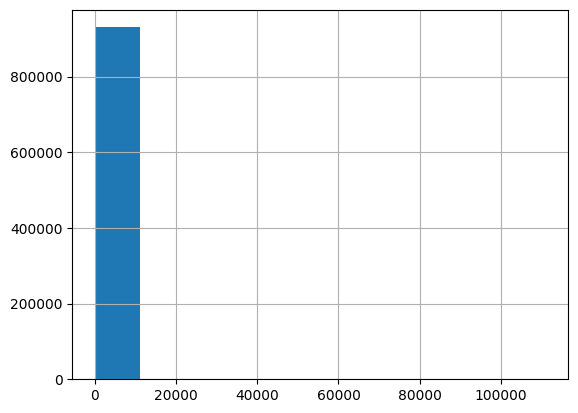

In [12]:
top_tracks_by_users = (
    interactions_clean
    .groupby("track_id")["user_id"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="users_count")
)

top_tracks_by_users["users_count"].hist()

Наиболее популярные жанры

In [13]:
# 1. Считаем, сколько раз слушали каждый трек
track_listens = (
    interactions_clean["track_id"]
    .value_counts()
    .reset_index()
)

track_listens.columns = ["track_id", "listens_count"]


# 2. Разворачиваем список жанров
track_genres = (
    tracks_clean[["track_id", "genres"]]
    .explode("genres")
    .rename(columns={"genres": "genre_id"})
)

# 3. Соединяем треки с количеством прослушиваний и жанрами
track_genres_listens = track_genres.merge(
    track_listens,
    on="track_id",
    how="inner"
)

# 4. Суммируем прослушивания по жанрам
genre_popularity = (
    track_genres_listens
    .groupby("genre_id", as_index=False)["listens_count"]
    .sum()
    .sort_values("listens_count", ascending=False)
)

genre_popularity.head(20)

,genre_id,listens_count
10,11,55551134
70,75,37799684
89,102,31085569
19,20,26626234
2,3,25303695
63,68,18376062
15,16,16267222
1,2,13166147
13,14,12769694
40,44,12194520


In [14]:
genre_names = (
    catalog_names[catalog_names["type"] == "genre"][["id", "name"]]
    .rename(columns={"id": "genre_id", "name": "genre_name"})
)

genre_popularity = genre_popularity.merge(
    genre_names,
    on="genre_id",
    how="left"
)

genre_popularity = genre_popularity[
    ["genre_id", "genre_name", "listens_count"]
].sort_values("listens_count", ascending=False)

genre_popularity.head(20)

,genre_id,genre_name,listens_count
0,11,pop,55551134
1,75,rap,37799684
2,102,allrock,31085569
3,20,ruspop,26626234
4,3,rusrap,25303695
5,68,electronics,18376062
6,16,dance,16267222
7,2,rusrock,13166147
8,14,rock,12769694
9,44,foreignrap,12194520


Треки, которые никто не прослушал

In [15]:
listened_track_ids = interactions_clean["track_id"].unique()

not_listened_tracks = tracks_clean[
    ~tracks_clean["track_id"].isin(listened_track_ids)
].copy()

print("Треков, которые никто не послушал:", len(not_listened_tracks))

not_listened_tracks.head()

Треков, которые никто не послушал: 0


,track_id,albums,artists,genres


# Преобразование данных

Преобразуем данные в формат, более пригодный для дальнейшего использования в расчётах рекомендаций.

In [16]:
events = interactions_clean.copy()
events = events.rename(columns={"track_id": "item_id", "track_seq": "item_seq"})
items = tracks_clean.copy()
items = items.rename(columns={"track_id": "item_id"})

# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [17]:
import os
from dotenv import load_dotenv

load_dotenv()

s3_access_key = os.getenv("S3_ACCESS_KEY")
s3_secret_key = os.getenv("S3_SECRET_KEY")
s3_endpoint_url = os.getenv("S3_ENDPOINT_URL")
s3_bucket_name = os.getenv("S3_BUCKET_NAME")

In [18]:
items.to_parquet(
    f"s3://{s3_bucket_name}/recsys/data/items.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)
events.to_parquet(
    f"s3://{s3_bucket_name}/recsys/data/events.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)


# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv

load_dotenv()

s3_access_key = os.getenv("S3_ACCESS_KEY")
s3_secret_key = os.getenv("S3_SECRET_KEY")
s3_endpoint_url = os.getenv("S3_ENDPOINT_URL")
s3_bucket_name = os.getenv("S3_BUCKET_NAME")

storage_options = {
    "key": s3_access_key,
    "secret": s3_secret_key,
    "client_kwargs": {
        "endpoint_url": s3_endpoint_url,
    },
}



In [2]:
items = pd.read_parquet(
    f"s3://{s3_bucket_name}/recsys/data/items.parquet",
    engine="pyarrow",
    storage_options=storage_options,
)

events = pd.read_parquet(
    f"s3://{s3_bucket_name}/recsys/data/events.parquet",
    engine="pyarrow",
    storage_options=storage_options,
)

display(items.head())
display(events.head())

display(items.shape)
display(events.shape)

,item_id,albums,artists,genres
0,26,"[3, 2490753]",[16],"[11, 21]"
1,38,"[3, 2490753]",[16],"[11, 21]"
2,135,"[12, 214, 2490809]",[84],[11]
3,136,"[12, 214, 2490809]",[84],[11]
4,138,"[12, 214, 322, 72275, 72292, 91199, 213505, 24...",[84],[11]


,user_id,item_id,item_seq,started_at
0,0,99262,1,2022-07-17
1,0,589498,2,2022-07-19
2,0,590262,3,2022-07-21
3,0,590303,4,2022-07-22
4,0,590692,5,2022-07-22


(932664, 4)

(214720738, 4)

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [3]:
events["started_at"] = pd.to_datetime(events["started_at"])

split_date = pd.Timestamp("2022-12-16")

events_train = events[
    events["started_at"] < split_date
].copy()

events_test = events[
    events["started_at"] >= split_date
].copy()

In [4]:
print("events_train:", events_train.shape)
print("events_test:", events_test.shape)

print("Максимальная дата в train:", events_train["started_at"].max())
print("Минимальная дата в test:", events_test["started_at"].min())

events_train: (201204460, 4)
events_test: (13516278, 4)
Максимальная дата в train: 2022-12-15 00:00:00
Минимальная дата в test: 2022-12-16 00:00:00


# Топ популярных

Рассчитаем рекомендации как топ популярных.

In [5]:
import numpy as np
TOP_N = 100

top_popular = (
    events_train
    .groupby("item_id", as_index=False)
    .agg(
        listens_count=("user_id", "count"),
        users_count=("user_id", "nunique")
    )
    .sort_values(
        ["listens_count", "users_count"],
        ascending=False
    )
    .head(TOP_N)
    .copy()
)

top_popular["rank"] = np.arange(1, len(top_popular) + 1)

top_popular = top_popular[
    ["item_id", "rank", "listens_count", "users_count"]
]

top_popular.head()

,item_id,rank,listens_count,users_count
8215,53404,1,110026,110026
451664,33311009,2,101076,101076
24433,178529,3,100866,100866
478765,35505245,4,95523,95523
341295,24692821,5,84153,84153


In [6]:
top_popular.to_parquet(
    f"s3://{s3_bucket_name}/recsys/recommendations/top_popular.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)

# Персональные

Рассчитаем персональные рекомендации.

In [7]:
# Число прослушиваний используем как неявную обратную связь.
events_als = (
    events_train
    .groupby(["user_id", "item_id"], as_index=False)
    .size()
    .rename(columns={"size": "weight"})
)
events_als["weight"] = np.log1p(events_als["weight"]).astype("float32")

In [8]:
import sklearn.preprocessing

user_encoder = sklearn.preprocessing.LabelEncoder()
user_encoder.fit(events_als["user_id"])
events_als["user_id_enc"] = user_encoder.transform(events_als["user_id"])

item_encoder = sklearn.preprocessing.LabelEncoder()
item_encoder.fit(items["item_id"])
items["item_id_enc"] = item_encoder.transform(items["item_id"])
events_als["item_id_enc"] = item_encoder.transform(events_als["item_id"])

In [9]:
import scipy

user_item_matrix = scipy.sparse.csr_matrix(
    (
        events_als["weight"],
        (events_als["user_id_enc"], events_als["item_id_enc"]),
    ),
    shape=(len(user_encoder.classes_), len(item_encoder.classes_)),
    dtype=np.float32,
)

In [10]:
from implicit.als import AlternatingLeastSquares

als_model = AlternatingLeastSquares(
    factors=50,
    iterations=50,
    regularization=0.05,
    random_state=42,
    use_gpu=True
)
als_model.fit(user_item_matrix)

/home/nikita/projects/mle-project-sprint-4-v001/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [02:14<00:00,  2.69s/it]


In [11]:
def get_recommendations_als(
    user_item_matrix,
    model,
    user_id,
    user_encoder,
    item_encoder,
    include_seen=True,
    n=5,
):
    """Возвращает отранжированные рекомендации для заданного пользователя."""
    user_id_enc = user_encoder.transform([user_id])[0]
    recommendations = model.recommend(
        user_id_enc,
        user_item_matrix[user_id_enc],
        filter_already_liked_items=not include_seen,
        N=n,
    )
    recommendations = pd.DataFrame(
        {"item_id_enc": recommendations[0], "score": recommendations[1]}
    )
    recommendations["item_id"] = item_encoder.inverse_transform(
        recommendations["item_id_enc"]
    )
    return recommendations

In [12]:
# user_ids_encoded = np.arange(len(user_encoder.classes_))

# als_recommendations = als_model.recommend(
#     user_ids_encoded,
#     user_item_matrix[user_ids_encoded],
#     filter_already_liked_items=True,
#     N=100,
# )

In [13]:
import numpy as np
from tqdm.auto import tqdm

# Получаем рекомендации батчами, чтобы видеть прогресс
user_ids_encoded = np.arange(len(user_encoder.classes_))

batch_size = 10_000  

all_item_ids = []
all_scores = []

for start in tqdm(
    range(0, len(user_ids_encoded), batch_size),
    desc="ALS recommendations",
):
    end = min(start + batch_size, len(user_ids_encoded))
    batch_user_ids = user_ids_encoded[start:end]

    batch_item_ids, batch_scores = als_model.recommend(
        batch_user_ids,
        user_item_matrix[batch_user_ids],
        filter_already_liked_items=True,
        N=100,
    )

    all_item_ids.append(batch_item_ids)
    all_scores.append(batch_scores)

# Чтобы формат остался похожим на обычный implicit.recommend()
als_recommendations = (
    np.vstack(all_item_ids),
    np.vstack(all_scores),
)

ALS recommendations: 100%|██████████| 135/135 [00:44<00:00,  3.04it/s]


In [14]:
item_ids_enc = als_recommendations[0]
als_scores = als_recommendations[1]

personal_als = pd.DataFrame(
    {
        "user_id_enc": user_ids_encoded,
        "item_id_enc": item_ids_enc.tolist(),
        "score": als_scores.tolist(),
    }
).explode(["item_id_enc", "score"], ignore_index=True)

personal_als["item_id_enc"] = personal_als["item_id_enc"].astype("int32")
personal_als["score"] = personal_als["score"].astype("float32")

In [15]:
personal_als["user_id"] = user_encoder.inverse_transform(
    personal_als["user_id_enc"]
)
personal_als["item_id"] = item_encoder.inverse_transform(
    personal_als["item_id_enc"]
)

personal_als["rank"] = (
    personal_als.groupby("user_id", sort=False).cumcount() + 1
)
personal_als = personal_als[["user_id", "item_id", "score", "rank"]]

In [16]:
print("Пользователей с рекомендациями:", personal_als["user_id"].nunique())
print("Всего рекомендаций:", len(personal_als))
personal_als.head()

Пользователей с рекомендациями: 1341269
Всего рекомендаций: 134126900


,user_id,item_id,score,rank
0,0,29213451,0.009276,1
1,0,27077792,0.008632,2
2,0,18860,0.008118,3
3,0,25903468,0.007861,4
4,0,19722850,0.007808,5


In [17]:
personal_als.to_parquet(
    f"s3://{s3_bucket_name}/recsys/recommendations/personal_als.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

In [18]:
SIMILAR_N = 10
item_ids_encoded = np.arange(len(item_encoder.classes_))

similar_item_ids_encoded, similarity_scores = als_model.similar_items(
    item_ids_encoded,
    N=SIMILAR_N + 1,
)

similar_als = pd.DataFrame(
    {
        "item_id_enc": item_ids_encoded,
        "similar_item_id_enc": similar_item_ids_encoded.tolist(),
        "score": similarity_scores.tolist(),
    }
).explode(["similar_item_id_enc", "score"], ignore_index=True)

similar_als["similar_item_id_enc"] = similar_als["similar_item_id_enc"].astype("int32")
similar_als["score"] = similar_als["score"].astype("float32")

In [19]:
# Исключаем исходный трек из списка похожих и оставляем топ-N.
similar_als = similar_als[
    similar_als["item_id_enc"] != similar_als["similar_item_id_enc"]
].copy()
similar_als = similar_als.groupby("item_id_enc", sort=False).head(SIMILAR_N)

similar_als["item_id"] = item_encoder.inverse_transform(similar_als["item_id_enc"])
similar_als["similar_item_id"] = item_encoder.inverse_transform(
    similar_als["similar_item_id_enc"]
)
similar_als["rank"] = similar_als.groupby("item_id_enc", sort=False).cumcount() + 1

similar_als = similar_als[["item_id", "similar_item_id", "score", "rank"]]
similar_als.to_parquet("similar_als.parquet", index=False)

print("Треков с похожими:", similar_als["item_id"].nunique())
print("Всего пар похожих треков:", len(similar_als))
similar_als.head()

Треков с похожими: 932664
Всего пар похожих треков: 9326640


,item_id,similar_item_id,score,rank
1,26,21846409,0.819496,1
2,26,26343802,0.817163,2
3,26,20111365,0.814021,3
4,26,1293112,0.778046,4
5,26,25340391,0.773326,5


In [31]:
similar_als.to_parquet(
    f"s3://{s3_bucket_name}/recsys/recommendations/similar.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

In [21]:
# Признаки считаем только по train, чтобы не допустить утечку из будущего.
item_features = (
    events_train.groupby("item_id", as_index=False)
    .agg(
        item_listens=("user_id", "size"),
        item_users=("user_id", "nunique"),
    )
)
item_features["item_listens_log"] = np.log1p(item_features["item_listens"]).astype("float32")
item_features["item_users_log"] = np.log1p(item_features["item_users"]).astype("float32")
item_features = item_features[["item_id", "item_listens_log", "item_users_log"]]

user_features = (
    events_train.groupby("user_id", as_index=False)
    .agg(
        user_listens=("item_id", "size"),
        user_items=("item_id", "nunique"),
    )
)
user_features["user_listens_log"] = np.log1p(user_features["user_listens"]).astype("float32")
user_features["user_items_log"] = np.log1p(user_features["user_items"]).astype("float32")
user_features = user_features[["user_id", "user_listens_log", "user_items_log"]]

display(item_features.head())
display(user_features.head())

,item_id,item_listens_log,item_users_log
0,26,1.791759,1.791759
1,38,2.197225,2.197225
2,135,2.833213,2.833213
3,136,2.079442,2.079442
4,138,2.890372,2.890372


,user_id,user_listens_log,user_items_log
0,0,3.295837,3.295837
1,1,3.610918,3.610918
2,2,2.639057,2.639057
3,3,3.496508,3.496508
4,4,5.459586,5.459586


In [22]:
# Добавляем признаки к ALS-кандидатам и размечаем прослушивания из test.
candidates_with_features = personal_als.rename(
    columns={"score": "als_score", "rank": "als_rank"}
)
candidates_with_features = candidates_with_features.merge(
    item_features, on="item_id", how="left"
)
candidates_with_features = candidates_with_features.merge(
    user_features, on="user_id", how="left"
)

test_labels = events_test[["user_id", "item_id"]].drop_duplicates().copy()
test_labels["target"] = np.int8(1)
candidates_with_features = candidates_with_features.merge(
    test_labels, on=["user_id", "item_id"], how="left"
)
candidates_with_features["target"] = (
    candidates_with_features["target"].fillna(0).astype("int8")
)

feature_names = [
    "als_score",
    "als_rank",
    "item_listens_log",
    "item_users_log",
    "user_listens_log",
    "user_items_log",
]

candidates_with_features.to_parquet("candidates_with_features.parquet", index=False)
print("Доля положительных кандидатов:", candidates_with_features["target"].mean())
candidates_with_features.head()

Доля положительных кандидатов: 0.0047377520840338515


,user_id,item_id,als_score,als_rank,item_listens_log,item_users_log,user_listens_log,user_items_log,target
0,0,29213451,0.009276,1,10.617589,10.617589,3.295837,3.295837,0
1,0,27077792,0.008632,2,10.198170,10.198170,3.295837,3.295837,0
2,0,18860,0.008118,3,10.656883,10.656883,3.295837,3.295837,0
3,0,25903468,0.007861,4,10.098972,10.098972,3.295837,3.295837,0
4,0,19722850,0.007808,5,10.159601,10.159601,3.295837,3.295837,0


# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

In [24]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split

# Для обучения оставляем пользователей, у которых ALS нашёл хотя бы один
# будущий прослушанный трек, и ограничиваем число отрицательных примеров.
positive_users = candidates_with_features.loc[
    candidates_with_features["target"] == 1, "user_id"
].unique()
candidates_for_model = candidates_with_features[
    candidates_with_features["user_id"].isin(positive_users)
].copy()

positive_candidates = candidates_for_model[candidates_for_model["target"] == 1]
negative_candidates = (
    candidates_for_model[candidates_for_model["target"] == 0]
    .sample(frac=1, random_state=42)
    .groupby("user_id", group_keys=False)
    .head(10)
)
candidates_for_model = pd.concat(
    [positive_candidates, negative_candidates], ignore_index=True
)

# Делим по пользователям, чтобы рекомендации одного пользователя
# не попадали одновременно в обучение и валидацию.
train_users, validation_users = train_test_split(
    positive_users, test_size=0.2, random_state=42
)
train_candidates = candidates_for_model[
    candidates_for_model["user_id"].isin(train_users)
]
validation_candidates = candidates_for_model[
    candidates_for_model["user_id"].isin(validation_users)
]

train_pool = Pool(train_candidates[feature_names], label=train_candidates["target"])
validation_pool = Pool(
    validation_candidates[feature_names], label=validation_candidates["target"]
)

cb_model = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)
cb_model.fit(train_pool, eval_set=validation_pool, early_stopping_rounds=100)

print("Обучающих кандидатов:", len(train_candidates))
print("Валидационных кандидатов:", len(validation_candidates))

0:	test: 0.5986139	best: 0.5986139 (0)	total: 249ms	remaining: 20m 43s
100:	test: 0.6472004	best: 0.6472004 (100)	total: 24.6s	remaining: 19m 54s
200:	test: 0.6596590	best: 0.6596590 (200)	total: 49.8s	remaining: 19m 48s
300:	test: 0.6676112	best: 0.6676112 (300)	total: 1m 15s	remaining: 19m 39s
400:	test: 0.6729831	best: 0.6729831 (400)	total: 1m 41s	remaining: 19m 23s
500:	test: 0.6770759	best: 0.6770759 (500)	total: 2m 6s	remaining: 18m 57s
600:	test: 0.6804566	best: 0.6804566 (600)	total: 2m 32s	remaining: 18m 36s
700:	test: 0.6825329	best: 0.6825329 (700)	total: 2m 58s	remaining: 18m 16s
800:	test: 0.6846060	best: 0.6846060 (800)	total: 3m 25s	remaining: 17m 56s
900:	test: 0.6861355	best: 0.6861355 (900)	total: 3m 51s	remaining: 17m 31s
1000:	test: 0.6873910	best: 0.6873910 (1000)	total: 4m 17s	remaining: 17m 8s
1100:	test: 0.6885162	best: 0.6885162 (1100)	total: 4m 43s	remaining: 16m 44s
1200:	test: 0.6896447	best: 0.6896447 (1200)	total: 5m 9s	remaining: 16m 20s
1300:	test: 0.69

In [25]:
# Ранжируем полные списки кандидатов только для validation-пользователей.
candidates_to_rank = candidates_with_features[
    candidates_with_features["user_id"].isin(validation_users)
].copy()

candidates_to_rank["cb_score"] = cb_model.predict_proba(
    candidates_to_rank[feature_names]
)[:, 1]

candidates_to_rank = candidates_to_rank.sort_values(
    ["user_id", "cb_score"], ascending=[True, False]
)
candidates_to_rank["rank"] = (
    candidates_to_rank.groupby("user_id", sort=False).cumcount() + 1
)

MAX_RECOMMENDATIONS_PER_USER = 100
final_recommendations = candidates_to_rank[
    candidates_to_rank["rank"] <= MAX_RECOMMENDATIONS_PER_USER
][["user_id", "item_id", "cb_score", "rank"]].copy()

final_recommendations.to_parquet("final_recommendations.parquet", index=False)
print("Пользователей с итоговыми рекомендациями:", final_recommendations["user_id"].nunique())
final_recommendations.head()

Пользователей с итоговыми рекомендациями: 51812


,user_id,item_id,cb_score,rank
2314,23,17079396,0.436295,1
2398,23,28217177,0.420870,2
2302,23,29569939,0.410049,3
2323,23,27251717,0.375718,4
2376,23,26293905,0.346964,5


In [32]:
final_recommendations.to_parquet(
    f"s3://{s3_bucket_name}/recsys/recommendations/recommendations.parquet",
    engine="pyarrow",
    index=False,
    storage_options={
        "key": s3_access_key,
        "secret": s3_secret_key,
        "client_kwargs": {
            "endpoint_url": s3_endpoint_url
        }
    },
)

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

In [26]:
EVAL_K = 10
evaluation_users = np.asarray(validation_users)

# Один и тот же топ популярных рекомендуем каждому оцениваемому пользователю.
popular_for_evaluation = pd.MultiIndex.from_product(
    [evaluation_users, top_popular.head(EVAL_K)["item_id"]],
    names=["user_id", "item_id"],
).to_frame(index=False)
popular_for_evaluation["rank"] = (
    popular_for_evaluation.groupby("user_id", sort=False).cumcount() + 1
)

personal_for_evaluation = personal_als[
    personal_als["user_id"].isin(evaluation_users)
][["user_id", "item_id", "rank"]].copy()

final_for_evaluation = final_recommendations[
    ["user_id", "item_id", "rank"]
].copy()

ground_truth = events_test[
    events_test["user_id"].isin(evaluation_users)
][["user_id", "item_id"]].drop_duplicates()

# Вероятность встретить трек в истории train нужна для расчёта novelty.
train_item_probability = (
    events_train.groupby("item_id")["user_id"].nunique()
    / events_train["user_id"].nunique()
)

def evaluate_recommendations(recommendations, ground_truth, users, k, items_count):
    """Считает усреднённые по пользователям precision, recall, coverage и novelty."""
    recommendations_at_k = (
        recommendations[recommendations["rank"] <= k]
        [["user_id", "item_id"]]
        .drop_duplicates()
    )

    hits = recommendations_at_k.merge(
        ground_truth.assign(hit=1), on=["user_id", "item_id"], how="left"
    )
    hits["hit"] = hits["hit"].fillna(0)

    hits_by_user = hits.groupby("user_id")["hit"].sum().reindex(users, fill_value=0)
    recs_by_user = recommendations_at_k.groupby("user_id").size().reindex(users, fill_value=0)
    relevant_by_user = ground_truth.groupby("user_id").size().reindex(users, fill_value=0)

    precision = (hits_by_user / recs_by_user.replace(0, np.nan)).fillna(0).mean()
    recall = (hits_by_user / relevant_by_user.replace(0, np.nan)).fillna(0).mean()
    coverage = recommendations_at_k["item_id"].nunique() / items_count

    probabilities = recommendations_at_k["item_id"].map(train_item_probability)
    probabilities = probabilities.fillna(1 / max(events_train["user_id"].nunique(), 1))
    novelty = (-np.log2(probabilities.clip(lower=1e-12))).mean()

    return {
        "precision": precision,
        "recall": recall,
        "coverage": coverage,
        "novelty": novelty,
    }

In [27]:
metrics = pd.DataFrame(
    {
        "top_popular": evaluate_recommendations(
            popular_for_evaluation, ground_truth, evaluation_users, EVAL_K, items["item_id"].nunique()
        ),
        "personal_als": evaluate_recommendations(
            personal_for_evaluation, ground_truth, evaluation_users, EVAL_K, items["item_id"].nunique()
        ),
        "catboost": evaluate_recommendations(
            final_for_evaluation, ground_truth, evaluation_users, EVAL_K, items["item_id"].nunique()
        ),
    }
).T

metrics.index.name = "model"
metrics.to_csv("recommendation_metrics.csv")
display(metrics.style.format("{:.4f}"))

,precision,recall,coverage,novelty
model,,,,
top_popular,0.0067,0.0058,0.0000,3.9168
personal_als,0.0374,0.0529,0.0024,5.0227
catboost,0.0673,0.0864,0.0054,5.5879


# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.

In [28]:
# Сравним итоговую модель с базовыми подходами.
comparison = pd.DataFrame(index=["vs_top_popular", "vs_personal_als"])
comparison["precision_uplift_pct"] = [
    (metrics.loc["catboost", "precision"] / metrics.loc["top_popular", "precision"] - 1) * 100,
    (metrics.loc["catboost", "precision"] / metrics.loc["personal_als", "precision"] - 1) * 100,
]
comparison["recall_uplift_pct"] = [
    (metrics.loc["catboost", "recall"] / metrics.loc["top_popular", "recall"] - 1) * 100,
    (metrics.loc["catboost", "recall"] / metrics.loc["personal_als", "recall"] - 1) * 100,
]
comparison["coverage_change_pct"] = [
    (metrics.loc["catboost", "coverage"] - metrics.loc["top_popular", "coverage"]) * 100,
    (metrics.loc["catboost", "coverage"] - metrics.loc["personal_als", "coverage"]) * 100,
]
comparison["novelty_change"] = [
    metrics.loc["catboost", "novelty"] - metrics.loc["top_popular", "novelty"],
    metrics.loc["catboost", "novelty"] - metrics.loc["personal_als", "novelty"],
]

comparison.to_csv("model_comparison.csv")
display(comparison.style.format("{:+.2f}"))

,precision_uplift_pct,recall_uplift_pct,coverage_change_pct,novelty_change
vs_top_popular,+901.55,+1393.12,+0.54,+1.67
vs_personal_als,+80.08,+63.15,+0.30,+0.57


In [30]:
best_precision_model = metrics["precision"].idxmax()
best_recall_model = metrics["recall"].idxmax()
best_coverage_model = metrics["coverage"].idxmax()
best_novelty_model = metrics["novelty"].idxmax()

print(f"1. Лучшая precision@{EVAL_K}: {best_precision_model} "
      f"({metrics.loc[best_precision_model, 'precision']:.4f}).")
print(f"2. Лучшая recall@{EVAL_K}: {best_recall_model} "
      f"({metrics.loc[best_recall_model, 'recall']:.4f}).")
print(f"3. Лучшее покрытие каталога: {best_coverage_model} "
      f"({metrics.loc[best_coverage_model, 'coverage']:.4f}).")
print(f"4. Наиболее новые рекомендации: {best_novelty_model} "
      f"({metrics.loc[best_novelty_model, 'novelty']:.4f}).")
print(f"5. Подготовлено {len(top_popular):,} популярных рекомендаций, "
      f"{len(personal_als):,} персональных рекомендаций и "
      f"{len(similar_als):,} пар похожих треков.")
print(f"6. Итоговая модель сформировала {len(final_recommendations):,} рекомендаций "
      f"для {final_recommendations['user_id'].nunique():,} validation-пользователей.")
print("7. Для финальной unbiased-оценки следует выделить отдельный временной "
      "контрольный период, не используемый при обучении и ранней остановке CatBoost.")

1. Лучшая precision@10: catboost (0.0673).
2. Лучшая recall@10: catboost (0.0864).
3. Лучшее покрытие каталога: catboost (0.0054).
4. Наиболее новые рекомендации: catboost (5.5879).
5. Подготовлено 100 популярных рекомендаций, 134,126,900 персональных рекомендаций и 9,326,640 пар похожих треков.
6. Итоговая модель сформировала 5,181,200 рекомендаций для 51,812 validation-пользователей.
7. Для финальной unbiased-оценки следует выделить отдельный временной контрольный период, не используемый при обучении и ранней остановке CatBoost.


По результатам оценки лучшим подходом стала двухэтапная рекомендательная система с ALS-генерацией кандидатов и ранжированием при помощи CatBoost. Итоговая модель показала лучшие значения по всем рассчитанным метрикам:

- `precision@10 = 0.0673`: в среднем среди десяти рекомендаций содержится около 0.67 трека, который пользователь прослушает в будущем;
- `recall@10 = 0.0864`: рекомендации находят около 8.64% будущих уникальных прослушиваний пользователя;
- `coverage@10 = 0.0054`: итоговые рекомендации охватывают около 0.54% каталога;
- `novelty@10 = 5.5879`: CatBoost чаще предлагает менее популярные и более неожиданные треки, чем базовые подходы.


В ходе работы были подготовлены 134 126 900 персональных рекомендаций, 9 326 640 пар похожих треков и 5 181 200 итоговых рекомендаций для 51 812 validation-пользователей. Такой объём позволяет использовать рассчитанные рекомендации и похожие треки в онлайн-сервисе без выполнения тяжёлых расчётов во время пользовательского запроса.
